In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 21 — Rates, equations, units and what data can identify

Observed NIST copper measurements; manufactured cosine derivative checks. Temperature is not a time axis.

This is an executed reference, not a learner assessment. Read the lesson and predict the results before running. All code is inspectable in `src/shape_lab/physics`. No model or dataset downloads occur.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
STAGE=21
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT.parent!=ROOT:ROOT=ROOT.parent
if not (ROOT/'pyproject.toml').exists():raise RuntimeError('Open this notebook within the extracted project.')
sys.path.insert(0,str(ROOT/'src'))
from shape_lab.physics import classical as c, constraints as con, gradients as grad, operators as op
hahn=pd.read_csv(ROOT/'data/physics/hahn1_excerpt.csv')
hahn_manifest=json.loads((ROOT/'data/physics/manifest.json').read_text())
OUT=ROOT/'physics/reports'/f'{STAGE:02d}'
OUT.mkdir(parents=True,exist_ok=True)
def save_report(result):
    result={'stage':STAGE,'role':'executed teaching experiment; not learner assessment',**result}
    result['source_review_date']='2026-09-20'
    (OUT/'results.json').write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    print(json.dumps(result,indent=2))
def finish_figure(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=140,bbox_inches='tight');plt.show();plt.close()
print('Course:', ROOT.name, '| stage:', STAGE)


Course: course | stage: 21


## Predict a derivative
Compute the centered difference for cos(t). Predict the error change when h halves before running.

,h,estimated_derivative,absolute_error
0,0.200,-0.639931,0.004286
1,0.100,-0.643145,0.001073
2,0.050,-0.643949,0.000268
3,0.025,-0.644151,0.000067


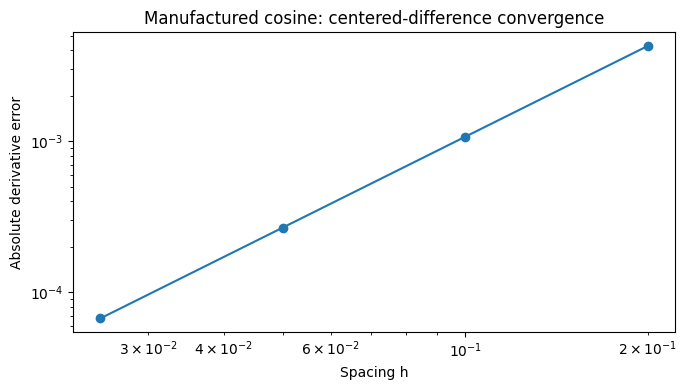

In [3]:
t=.7
hs=np.array([.2,.1,.05,.025])
est=(np.cos(t+hs)-np.cos(t-hs))/(2*hs)
errors=np.abs(est+np.sin(t))
display(pd.DataFrame({'h':hs,'estimated_derivative':est,'absolute_error':errors}))
assert np.all(errors[:-1]/errors[1:]>3.9)
plt.figure(figsize=(7,4));plt.loglog(hs,errors,'o-');plt.xlabel('Spacing h');plt.ylabel('Absolute derivative error');plt.title('Manufactured cosine: centered-difference convergence');finish_figure('derivative')

## Measured data has an axis definition
This excerpt has temperature, not time. Its response scale is left as supplied; it is not a trajectory or a thermal-PDE field.

,source_observation,temperature_K,expansion_response
0,1,24.41,0.591
1,2,34.82,1.547
2,3,44.09,2.902
3,4,45.07,2.894
4,5,54.98,4.703


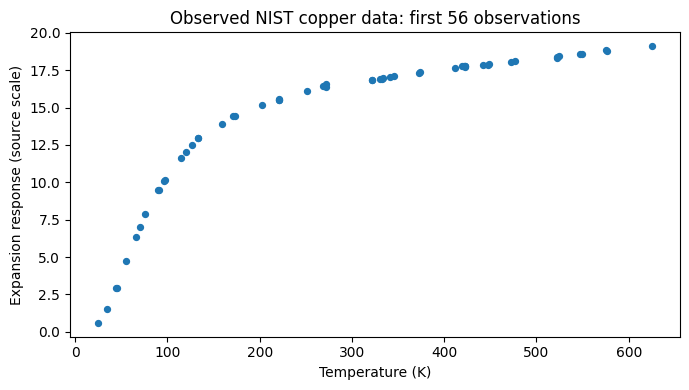

{
  "stage": 21,
  "role": "executed teaching experiment; not learner assessment",
  "data_kind": "analytic derivative validation plus observed static material data",
  "observed_rows": 56,
  "excerpt_sha256": "abcdeee10337f548d7072ce2284f6760e00cab3107bae472f1074efd9ab270b9",
  "first_secant_response_per_K": 0.09183477425552353,
  "centered_difference_errors": [
    0.004286203188420434,
    0.0010731594251268683,
    0.0002683904853413299,
    6.710391205544397e-05
  ],
  "unsupported": "No measured time derivatives or thermal diffusivity inferred.",
  "source_review_date": "2026-09-20"
}


In [4]:
secant=(hahn.expansion_response.iloc[1]-hahn.expansion_response.iloc[0])/(hahn.temperature_K.iloc[1]-hahn.temperature_K.iloc[0])
display(hahn.head())
assert hahn_manifest['time_axis'] is False
plt.figure(figsize=(7,4));plt.scatter(hahn.temperature_K,hahn.expansion_response,s=18);plt.xlabel('Temperature (K)');plt.ylabel('Expansion response (source scale)');plt.title('Observed NIST copper data: first 56 observations');finish_figure('copper')
save_report({'data_kind':'analytic derivative validation plus observed static material data','observed_rows':len(hahn),'excerpt_sha256':hahn_manifest['sha256'],'first_secant_response_per_K':float(secant),'centered_difference_errors':errors.tolist(),'unsupported':'No measured time derivatives or thermal diffusivity inferred.'})

## Independent explanation

Write the data origin, one supported conclusion and one unsupported conclusion. Change one parameter while preserving the comparison horizon or unit. Save your answer separately; successful reference execution is not proof that you understand the result.